# **This is the project title.**

Let's see if this shows up



Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

hello hello


In [2]:
!pip install -r requirements.txt --dry-run

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.4 MB/s eta 0:00:00
Processing /colabtools/dist/google_colab-1.0.0.tar.gz (from -r requirements.txt (line 168))
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/colabtools/dist/google_colab-1.0.0.tar.gz'



In [ ]:
---
title: "E3CI_Warm_Test_1"
format:
  html:
    code-fold: false
execute:
  echo: false
---

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx
import numpy as np
import matplotlib.colors as mcol
import matplotlib.cm as cm
import pylab as pl

In [ ]:
path_input = "C:/Users/NoemiAmbrosi/OneDrive - Net Service S.p.A/IFAB doc condivisi/Comunicazione/E3CI/Pubblicazione divulgativa E3CI/2024-2025"
path_input_2 = "C:/Users/NoemiAmbrosi/OneDrive - Net Service S.p.A/IFAB doc condivisi/Comunicazione/E3CI/Pubblicazione divulgativa E3CI/2024-2025"
path_output = "C:/Users/NoemiAmbrosi/OneDrive - Net Service S.p.A/IFAB doc condivisi/Comunicazione/E3CI/Pubblicazione divulgativa E3CI/2024-2025/Immagini/Mappe"

In [ ]:
df = pd.read_excel(
    f"{path_input}/componenti Regioni_25.xlsx",
    header=[0, 1],       # two header rows
    decimal=",",         # comma decimals
    na_values=["", " "],      # empty values
)

# Convert first column to datetime and make it index
df = df.rename(columns={'Unnamed: 0_level_0': 'time', 'Unnamed: 0_level_1' : '' })
df = df.set_index(('time', ''))

data_24_25 = df.tail(n=12)
data_24_25

Abruzzi                                                        \
             drought extreme max T extreme min T extreme prec extreme wind   
(time, )                                                                     
2024-09-01 -1.006216      1.327934     -0.146446     1.116421    -0.369789   
2024-10-01 -1.418592     -0.146645     -0.648442     0.373777    -0.143749   
2024-11-01 -0.691243     -0.304745     -0.471111    -0.456031     2.757799   
2024-12-01  0.031915      0.134604     -0.642467    -0.361734    -0.212161   
2025-01-01  0.575769      2.724066     -0.524487    -0.428505    -0.292833   
2025-02-01  0.017748     -0.404103     -0.622985     0.546245    -0.342543   
2025-03-01 -0.940069      0.090602     -0.383458     1.643953    -0.501470   
2025-04-01 -1.234046      5.317433     -0.496208    -0.350963     0.134865   
2025-05-01 -1.628832      0.199394     -0.176140    -0.038765    -0.492500   
2025-06-01  0.166063      6.240941     -0.730245    -0.409193    -0.236260   
2025-07-01 -0.262212      1.548821     -0.096221     1.499434     0.482837   
2025-08-01  0.222162      0.847133     -0.404407    -0.212674    -0.432684   

                               Basilicata                              ...  \
                fire      hail    drought extreme max T extreme min T  ...   
(time, )                                                               ...   
2024-09-01 -0.244429 -0.296959  -0.362576      0.732203     -0.640294  ...   
2024-10-01 -0.508710 -0.935140  -0.613510     -0.314604     -0.736204  ...   
2024-11-01 -0.952100 -0.252621   0.060319      0.176273     -0.386263  ...   
2024-12-01       NaN -0.100750   0.278188     -0.323104     -0.697865  ...   
2025-01-01       NaN -0.556740  -0.224866      1.971133     -0.511247  ...   
2025-02-01       NaN -1.658916  -0.411509     -0.583132     -0.515052  ...   
2025-03-01 -0.717097 -0.341704  -0.771781      1.359721     -0.327528  ...   
2025-04-01 -0.868652 -1.582186   0.489388      0.331177     -0.417149  ...   
2025-05-01 -0.265635 -0.623092  -0.028147     -0.209093     -0.348840  ...   
2025-06-01 -0.548221 -0.208438   0.873643      4.048666     -0.697514  ...   
2025-07-01 -0.861219 -0.008038   0.743469      2.522358     -0.465396  ...   
2025-08-01 -0.946051 -0.518855   0.496066      0.959845     -0.593853  ...   

           Valle D'aosta                        Veneto                \
            extreme wind      fire      hail   drought extreme max T   
(time, )                                                               
2024-09-01      1.588465       NaN  0.003825 -1.310380      4.299325   
2024-10-01     -0.508025       NaN -1.084773 -1.953356      2.753643   
2024-11-01     -0.495323       NaN -0.238266 -1.397348      0.142372   
2024-12-01     -0.229436       NaN -0.221889 -0.370126      2.056070   
2025-01-01     -0.519035       NaN -0.222932  0.633787      2.772060   
2025-02-01     -0.543128       NaN -1.267771 -0.480969     -0.250931   
2025-03-01     -0.420822       NaN -1.235047 -1.334086      0.523012   
2025-04-01     -0.494372       NaN -0.997913 -1.434771      0.995170   
2025-05-01     -0.209400       NaN -0.843082 -1.852227      1.141558   
2025-06-01     -0.361584 -0.674278 -0.800225  0.015057      3.478082   
2025-07-01      2.274275 -0.519783 -0.303148 -0.740881      2.175087   
2025-08-01     -0.598800 -0.686598 -0.309271 -0.971378      2.673206   

                                                                        
           extreme min T extreme prec extreme wind      fire      hail  
(time, )                                                                
2024-09-01     -0.064841     2.888567     1.484148 -0.337262 -0.485195  
2024-10-01     -0.529020     0.403983     0.531820 -0.347264 -1.026104  
2024-11-01     -0.458984    -0.615508    -0.450030 -0.518820  0.341439  
2024-12-01     -0.486167     0.105571    -0.102284 -0.950648 -1.025843  
2025-01-01     -0.353385    -0.061469     0.200187       NaN -0.666995  
2025-0

In [ ]:
regions_excel = ["Abruzzi","Basilicata","Calabria","Campania","Emilia-romagna","Friuli-venezia Giulia","Lazio",
                 "Liguria","Lombardia","Marche","Molise","Piemonte","Puglia","Sardegna","Sicilia",
                 "Toscana","Trentino-alto Adige","Trentino-alto Adige","Umbria","Valle D'aosta","Veneto"]



In [ ]:
n_months = 12
n_regions = len(regions_excel)

data_24_25_warm    = np.zeros((n_months,n_regions))
data_24_25_maxwarm = np.zeros(n_regions)
data_24_25_sumwarm = np.zeros(n_regions)
data_24_25_cumsumwarm = np.zeros(n_regions)

climate_index = 'extreme max T'

kk = 0
for ii in regions_excel:
    data_24_25_warm[:,kk]     = data_24_25.loc[:, (f"{ii}", f"{climate_index}")]
    data_24_25_maxwarm[kk]    = np.max(data_24_25_warm[:,kk])
    data_24_25_sumwarm[kk]    = np.sum(data_24_25_warm[:,kk]>1)
    counter = 0
    maxcounter = 0
    for jj in range(12):
        if data_24_25_warm[jj,kk]>1:
            counter += 1
        else:
            maxcounter = np.max([counter,maxcounter])
            counter = 0

    data_24_25_cumsumwarm[kk] = np.max([counter,maxcounter])
    kk += 1

# data_24_25_cold # numpy array lungo n_regions

In [ ]:
#| output: false
data_24_25_maxwarm

array([ 6.24094121,  4.04866598,  4.58773684,  7.25121109,  3.09003486,
        9.41394158, 10.73982844, 10.46868301,  4.80634439,  4.44816862,
        4.43211224,  5.40000955,  1.1662283 ,  4.48104188,  4.06434165,
        8.0113717 ,  9.39515912,  9.39515912,  7.92511166, 13.23837262,
        4.29932501])

In [ ]:
#| output: false
data_24_25_sumwarm

array([5., 4., 6., 8., 3., 9., 6., 8., 7., 2., 5., 5., 2., 6., 7., 7., 5.,
       5., 5., 8., 8.])

In [ ]:
#| output: false
data_24_25_cumsumwarm

array([2., 2., 3., 3., 2., 5., 3., 4., 4., 1., 3., 2., 1., 2., 2., 4., 3.,
       3., 3., 4., 4.])

## First visualization title

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

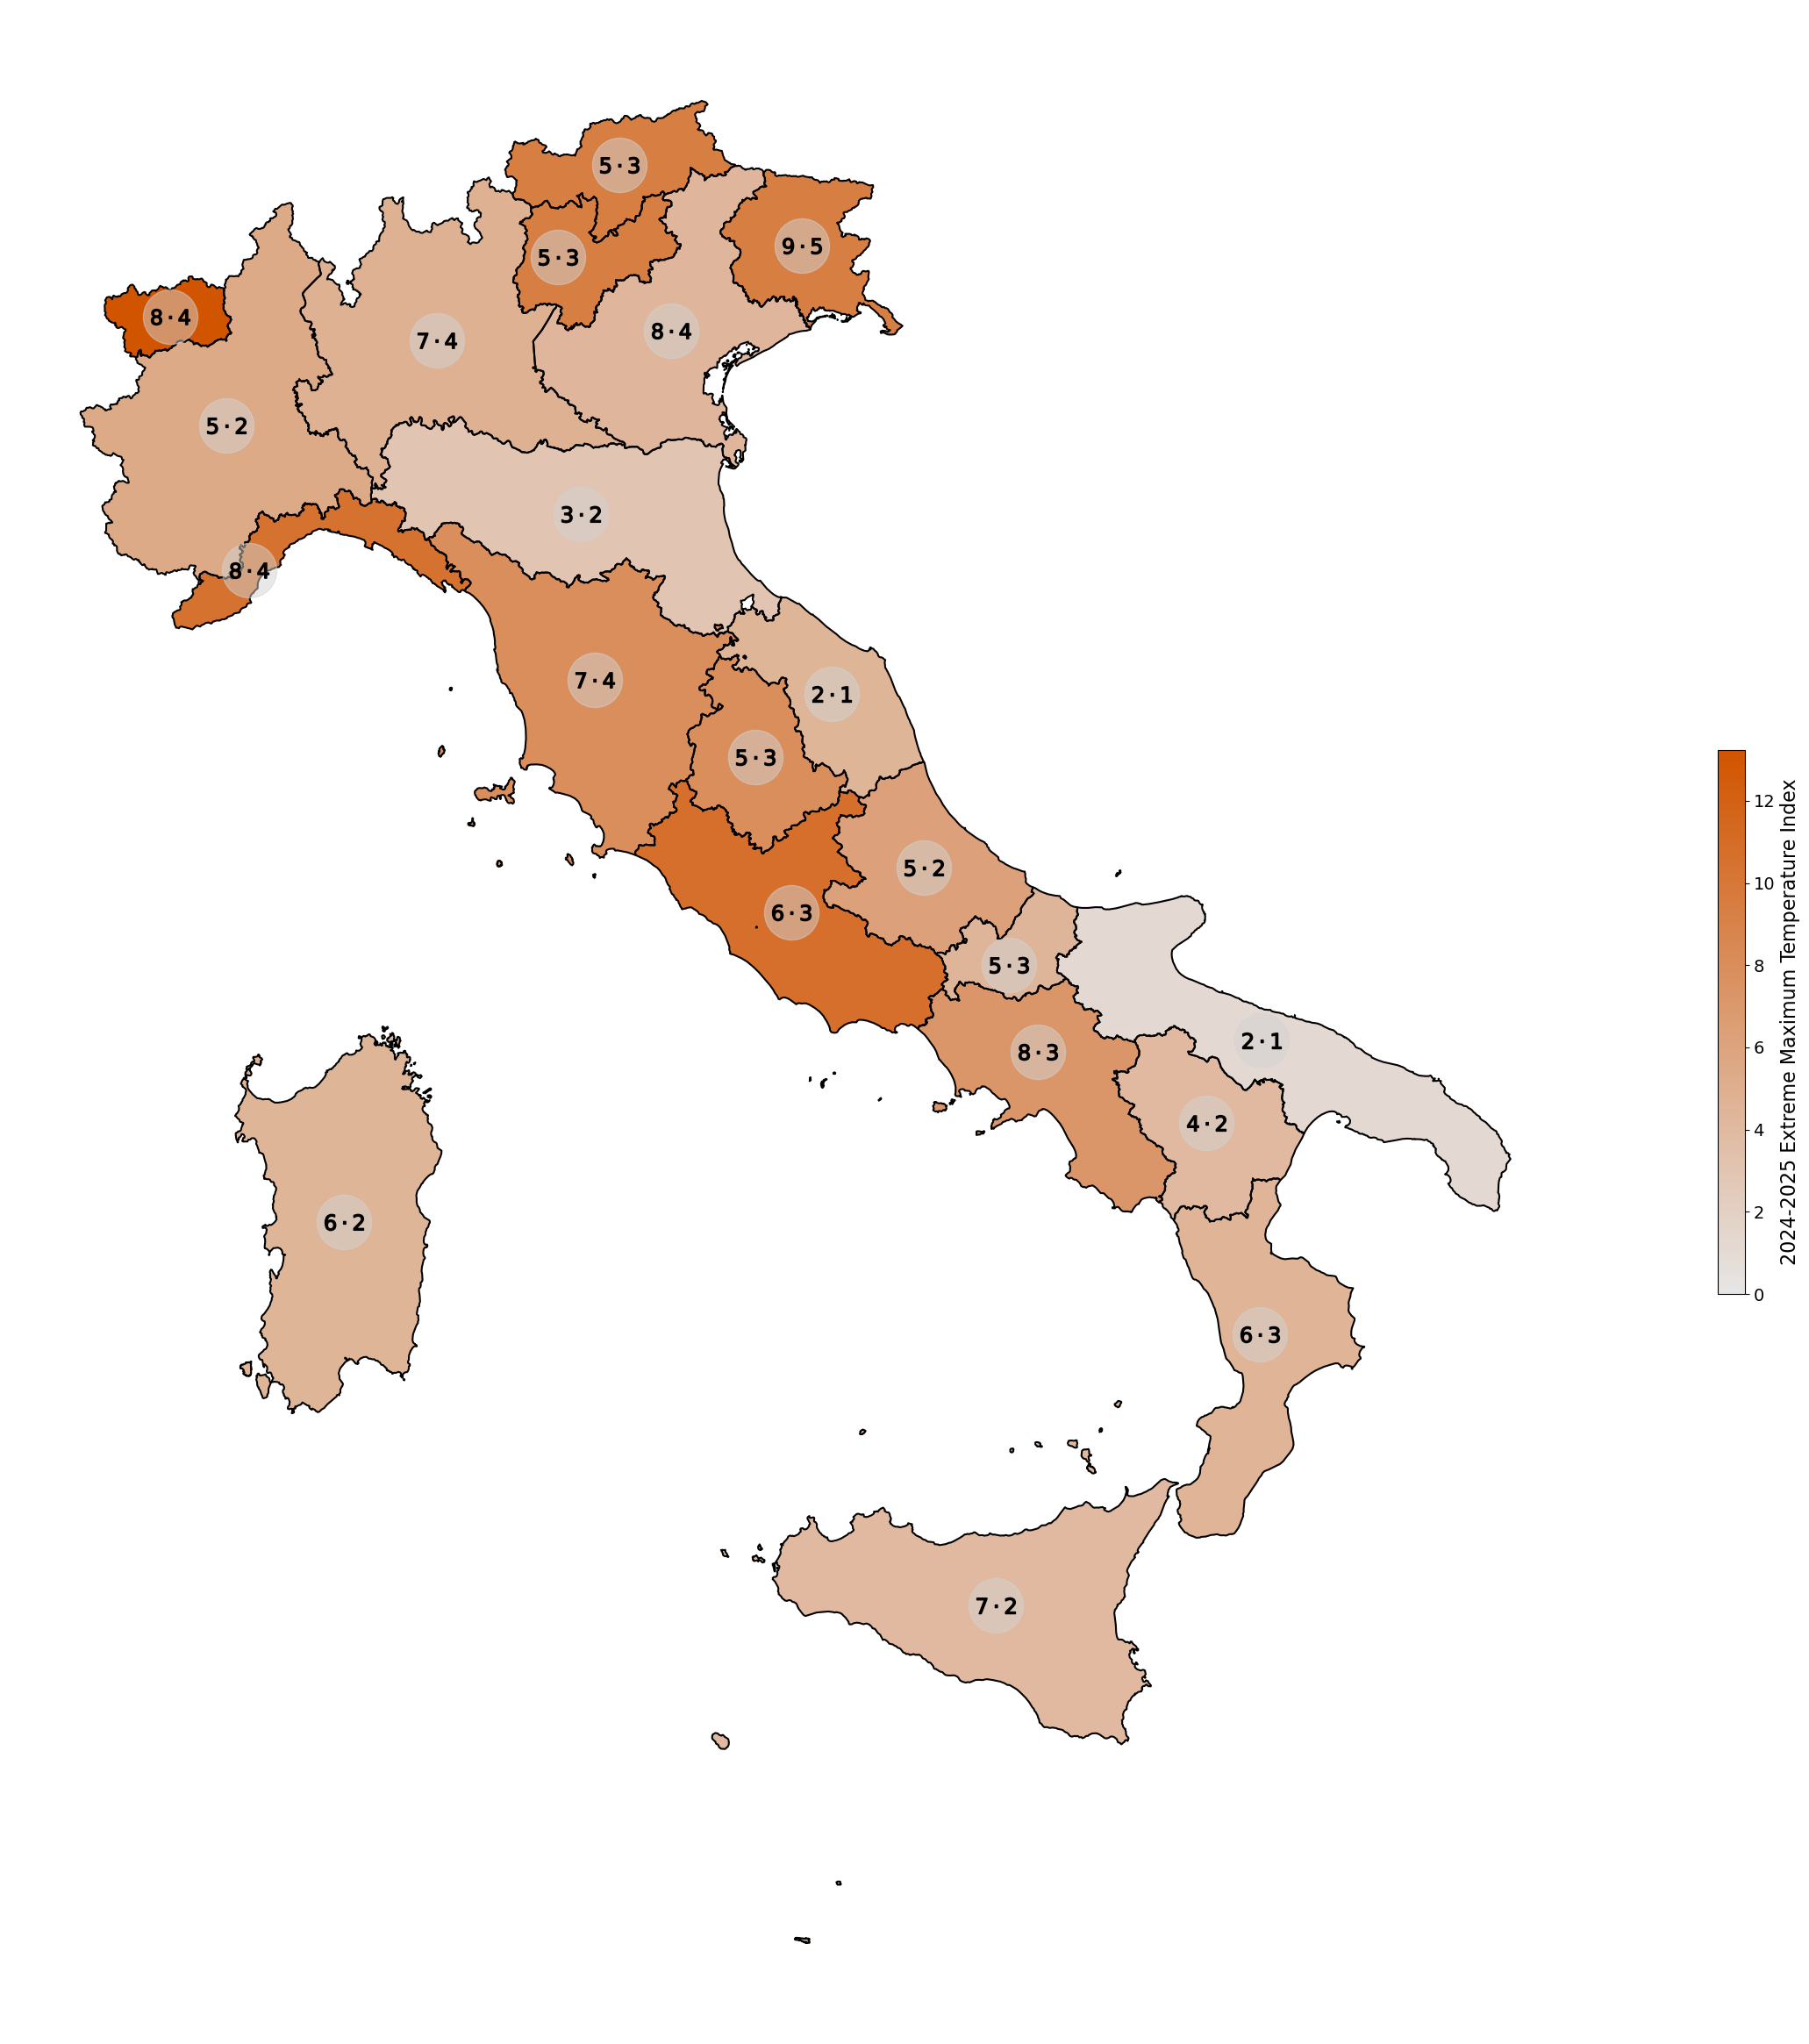

In [ ]:
data_dir = 'data/ref-nuts-2021-01m/'
path = data_dir + "NUTS_RG_01M_2021_3035_LEVL_2.json"
gdf = gpd.read_file(path)
path_lb = data_dir + "NUTS_LB_2021_3035_LEVL_2.json"
gdf_lb = gpd.read_file(path_lb)
# specify CRS (see the filename)
gdf.crs = "EPSG:3035"
#gdf_lb.crs = "EPSG:3035"

gdf_it    = gdf[gdf.CNTR_CODE == "IT"]
gdf_lb_it = gdf_lb[gdf_lb.CNTR_CODE == "IT"]

colors = [(0, '#E6E6E6'), (1, '#D15400')]

# Make a user-defined colormap.
cm1   = mcol.LinearSegmentedColormap.from_list('user_defined_cmap', colors)
cnorm = mcol.Normalize(vmin=0, vmax=max(data_24_25_maxwarm))
# Turn these into an object that can be used
cpick = cm.ScalarMappable(norm=cnorm,cmap=cm1)
cpick.set_array([])

# we need to transform the data into the 3857 CRS because of the Contextily base map
#gdf_it = gdf_it.to_crs("EPSG:3857")
#gdf_lb_it = gdf_lb_it.to_crs("EPSG:3857")

ax = gdf_it.plot(figsize=(40,30), color="lightgray")
regioni = ["Abruzzo","Basilicata","Calabria","Campania","Emilia-Romagna","Friuli-Venezia Giulia","Lazio","Liguria",
           "Lombardia","Marche","Molise","Piemonte","Puglia","Sardegna","Sicilia","Toscana","Provincia Autonoma di Trento",
           "Provincia Autonoma di Bolzano/Bozen","Umbria","Valle d’Aosta/Vallée d’Aoste","Veneto"]

index = np.random.rand(21)

gdf_it.boundary.plot(color="black", ax=ax)

kk = 0
for i in regioni:
    gdf_reg = gdf[gdf.NAME_LATN == i]
    gdf_lb_it_reg = gdf_lb_it[gdf_lb_it.NAME_LATN == i]
    #gdf_reg = gdf_reg.to_crs("EPSG:3857")

    gdf_reg.plot(figsize=(40,30), ax=ax, color=cpick.to_rgba(data_24_25_maxwarm[kk]))
    markersize = 1000 #*(np.max([[np.round(data_23_sumheat[kk])],[0]])+1)
    gdf_lb_it_reg.plot(figsize=(40,30), ax=ax, color="lightgray",markersize=2*markersize,marker='o',alpha=.5,zorder=10)
    gdf_lb_it_reg.plot(figsize=(40,30), ax=ax, color="black",markersize=markersize,marker=r'${%i\cdot%i}$' %(data_24_25_sumwarm[kk],data_24_25_cumsumwarm[kk]),zorder=10)
    #pl.text(gdf.lb_it, str(5), figsize=(20,15), ax=ax,  color="red", fontsize=12)

    kk += 1

# plot borders between the states green
plt.axis('off')
cbar = plt.colorbar(cpick,ax=ax, label="2024-2025 Extreme Maximum Temperature Index",fraction = .01)
cbar.set_label("2024-2025 Extreme Maximum Temperature Index", fontsize=16)
cbar.ax.tick_params(labelsize=14)
plt.savefig(f"{path_output}/Caldo italia")
plt.savefig(f"{path_output}/SVG/Caldo italia.svg", format="svg")
plt.show()
# add background map by OpenStreetMap
#ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.HOT)

## Second visualization title

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

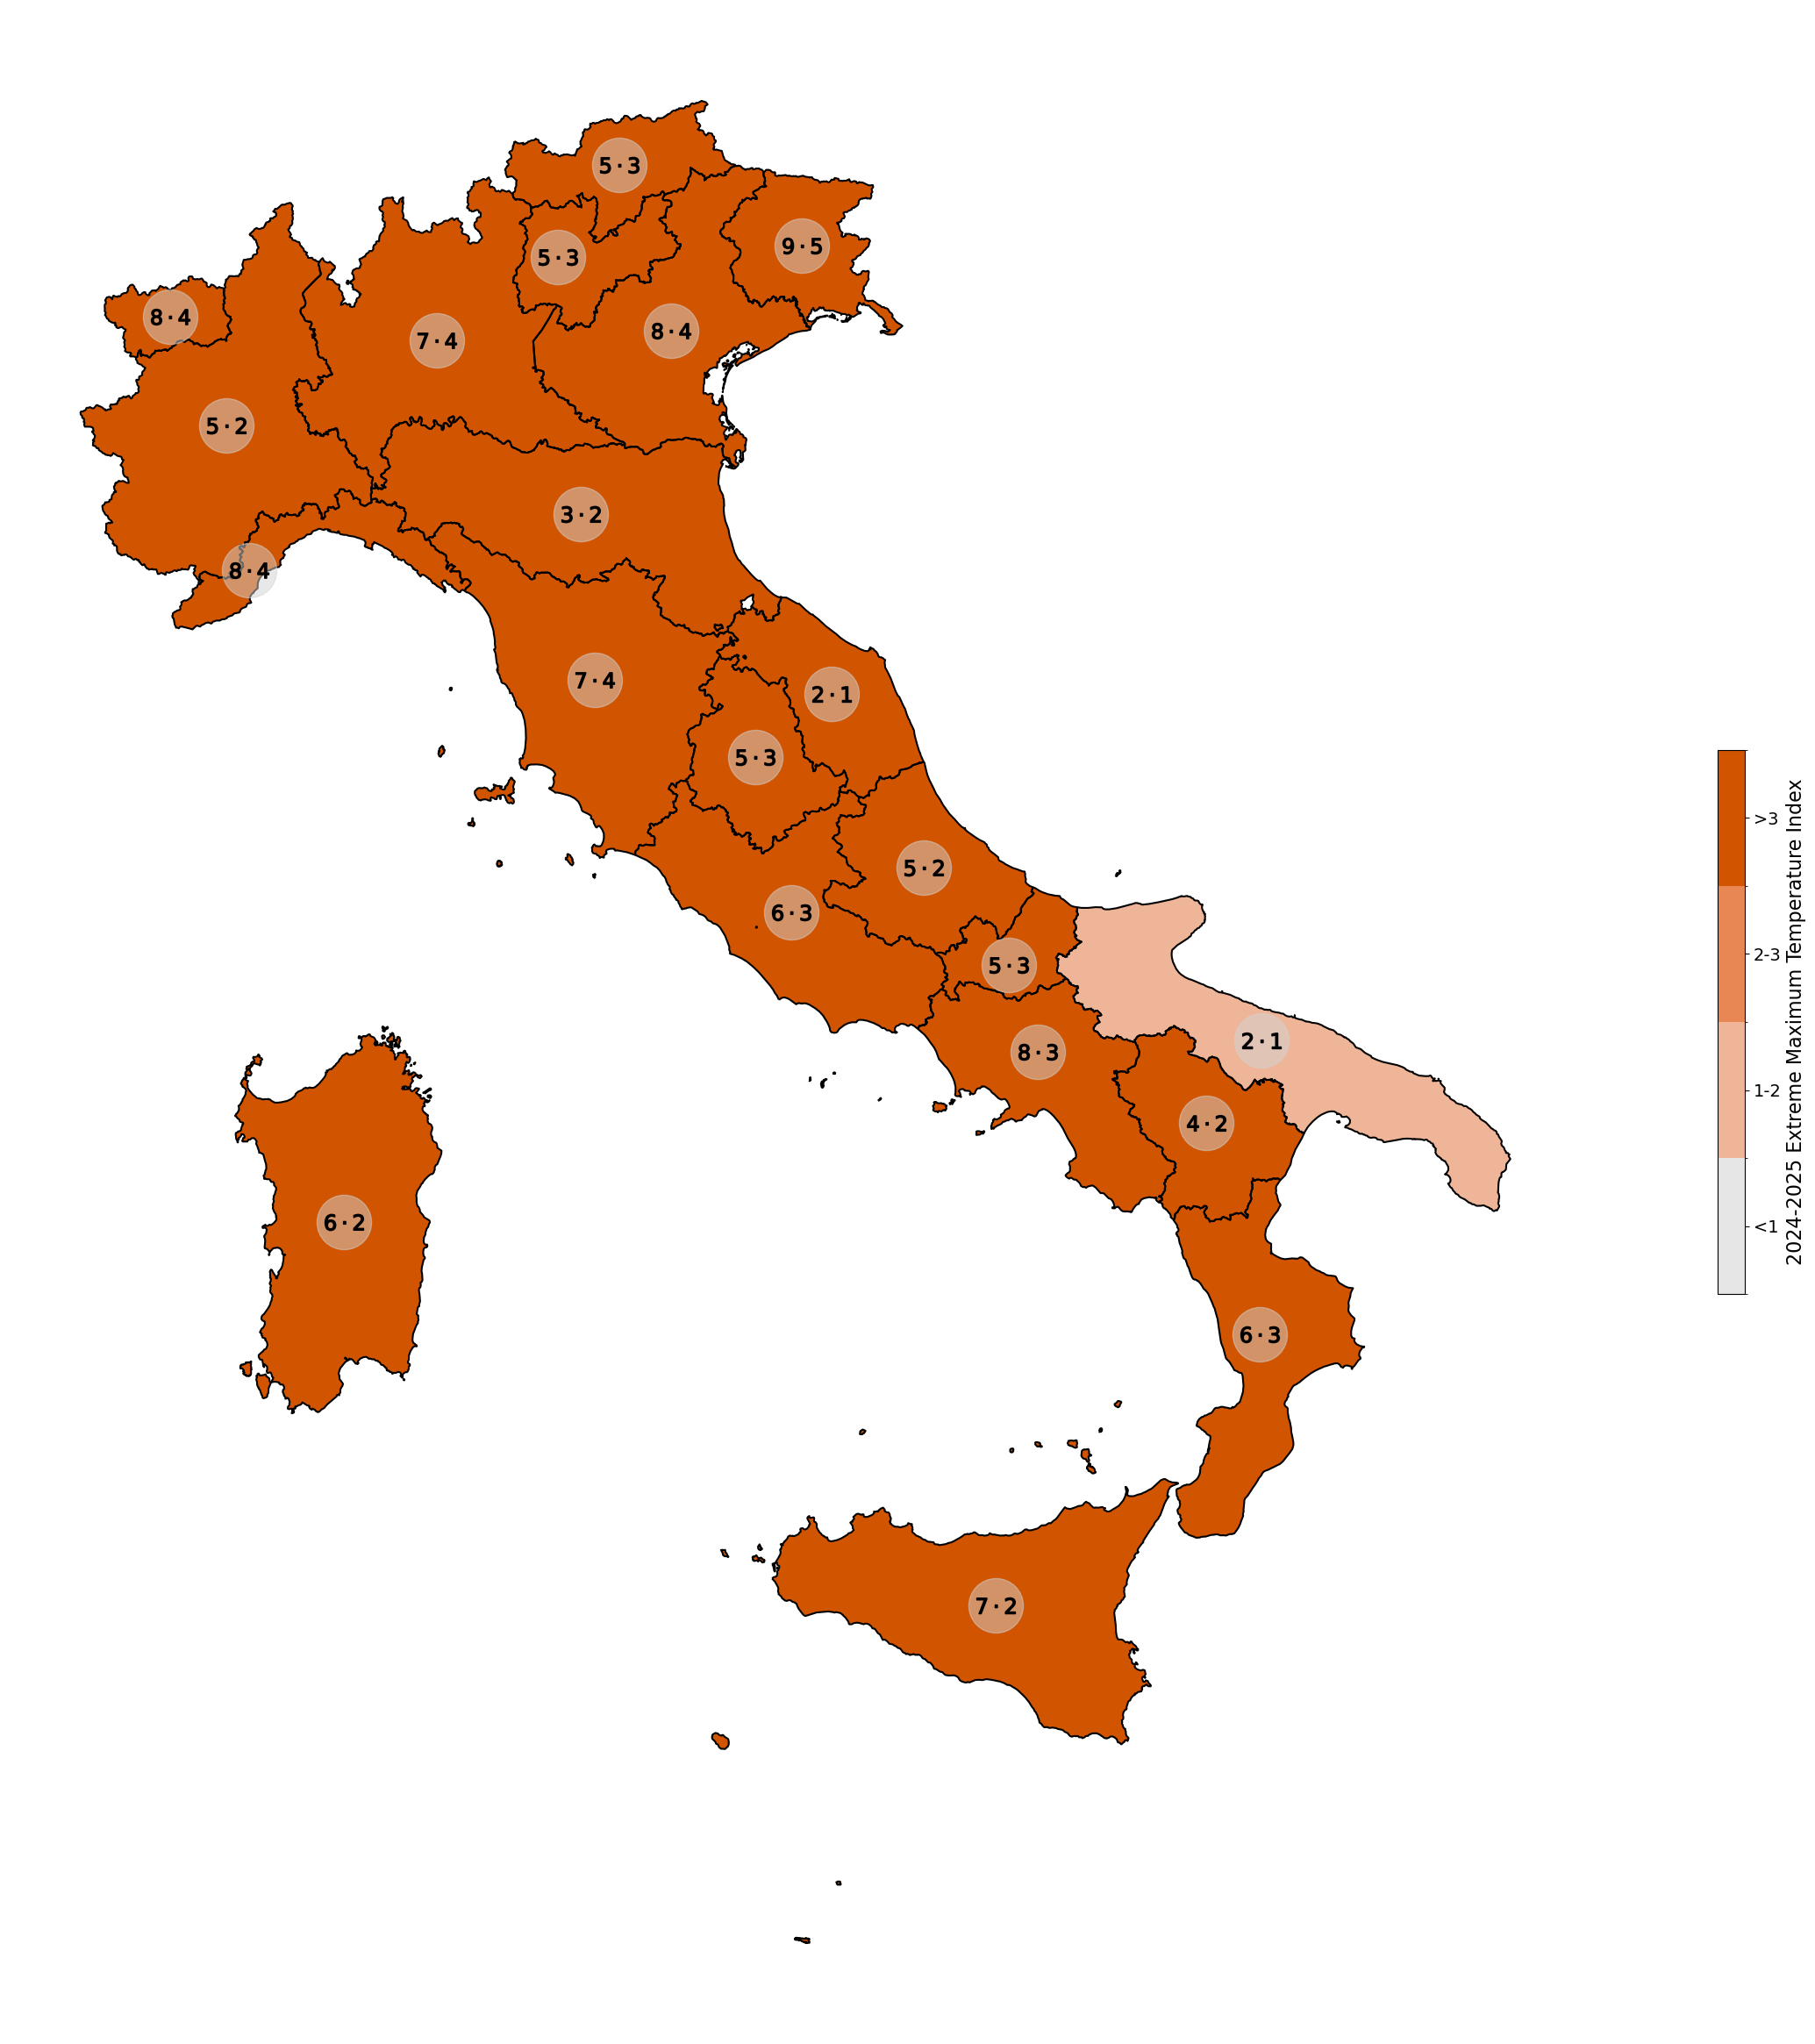

In [ ]:
data_dir = 'data/ref-nuts-2021-01m/'
path = data_dir + "NUTS_RG_01M_2021_3035_LEVL_2.json"
gdf = gpd.read_file(path)
path_lb = data_dir + "NUTS_LB_2021_3035_LEVL_2.json"
gdf_lb = gpd.read_file(path_lb)
# specify CRS (see the filename)
gdf.crs = "EPSG:3035"
#gdf_lb.crs = "EPSG:3035"

gdf_it = gdf[gdf.CNTR_CODE == "IT"]
gdf_lb_it = gdf_lb[gdf_lb.CNTR_CODE == "IT"]

# Define the color thresholds and corresponding colors
color_thresholds = [1, 2, 3]
# colors = ['#E6E6E6', '#C7E5EF', '#54B1CF', '#008AB8']
colors = ['#E6E6E6', '#EFB598', '#E88754', '#D15400']


# Create a custom colormap based on the defined color thresholds
cmap = mcol.ListedColormap(colors)
# Replace np.inf with a finite upper bound
max_data_value = np.max(data_24_25_maxwarm)
upper_bound = max(4, max_data_value + 0.5)  # Ensure upper bound is at least 4 or data max + 0.5
bounds = [0, 1, 2, 3, upper_bound]
norm = mcol.BoundaryNorm(bounds, cmap.N)

# Set up the plot
fig, ax = plt.subplots(figsize=(40, 30))

# Plot the base map
ax = gdf_it.plot(ax=ax, color="lightgray")

# Define the regions you want to highlight
regions = ["Abruzzo", "Basilicata", "Calabria", "Campania", "Emilia-Romagna", "Friuli-Venezia Giulia",
           "Lazio", "Liguria", "Lombardia", "Marche", "Molise", "Piemonte", "Puglia", "Sardegna",
           "Sicilia", "Toscana", "Provincia Autonoma di Trento", "Provincia Autonoma di Bolzano/Bozen",
           "Umbria", "Valle d’Aosta/Vallée d’Aoste", "Veneto"]

# Plot each region with the appropriate color based on the value
kk = 0
for i in regions:
    gdf_reg = gdf[gdf.NAME_LATN == i]
    gdf_lb_it_reg = gdf_lb_it[gdf_lb_it.NAME_LATN == i]

    # For each region, use the color corresponding to the value
    region_value = data_24_25_maxwarm[kk]  # Assuming this variable has the relevant data for each region
    gdf_reg.plot(ax=ax, color=cmap(norm(region_value)))

    # Optional: Plot light gray boundaries and labels (customized for each region)
    markersize = 1000
    gdf_lb_it_reg.plot(ax=ax, color="lightgray", markersize=2*markersize, marker='o', alpha=.5, zorder=10)
    gdf_lb_it_reg.plot(ax=ax, color="black", markersize=markersize, marker=r'${%i\cdot%i}$' % (data_24_25_sumwarm[kk], data_24_25_cumsumwarm[kk]), zorder=10)

    kk += 1

# Plot the boundaries between the regions in black
gdf_it.boundary.plot(ax=ax, color="black")

# Add color bar and finalize the plot
plt.axis('off')

# Add a color bar with custom tick labels
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="2024-2025 Extreme Maximum Temperature Index", fraction=0.01)
# Set custom tick positions and labels to match the bounds
cbar.set_ticks([0.5, 1.5, 2.5, 3 + (upper_bound-3)/2])
cbar.set_ticklabels(["<1", "1-2", "2-3", f">3"])
cbar.set_label("2024-2025 Extreme Maximum Temperature Index", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Save the plot
plt.savefig(f"{path_output}/Caldo italia discreta")
plt.savefig(f"{path_output}/SVG/Caldo italia discreta.svg", format="svg")
plt.show()

In [ ]:
#| include: false
# Create dataset
excel_italy = pd.read_csv(f"{path_input_2}/sara_giusto_spero.csv", sep = ";")
data_it     = pd.DataFrame(excel_italy)
data_it = data_it.rename(columns={'Unnamed: 0': 'time'})
data_it = data_it.set_index('time')
data_hail  = data_it['extreme max T']
values      = data_hail.tail(n=12).values

values = values.astype(float)
values

array([ 1.32306465,  1.21758908,  0.80829365,  1.88062258,  1.97996696,
       -0.22210168,  0.54360857,  0.93177937,  0.59133501,  4.89470854,
        2.43676448,  2.18729691])

## Third visualization title

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

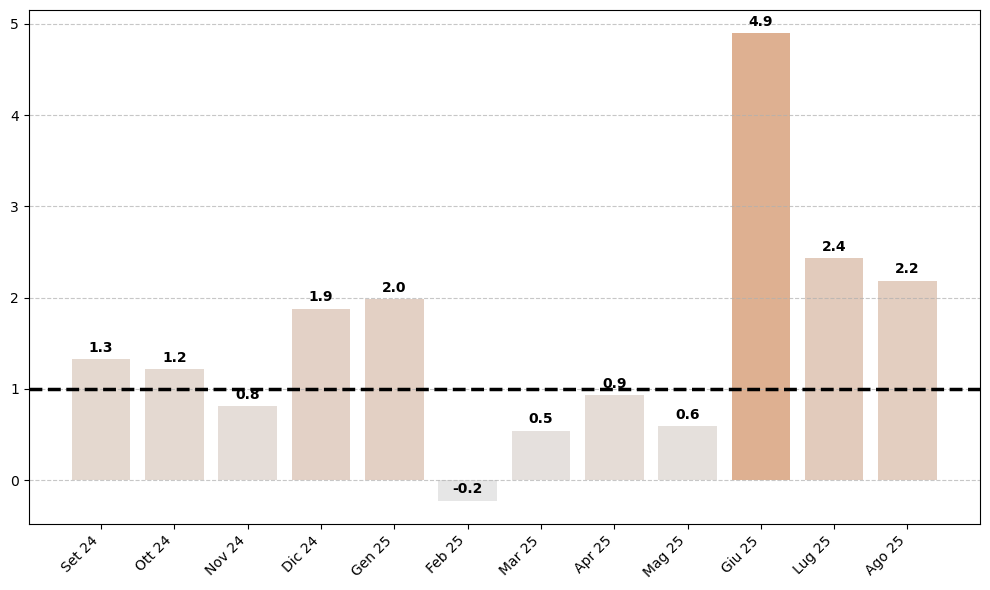

In [ ]:
# Create dataset
#values = [3.0959, 3.2286, 1.0916, 1.582, 2.4052, 1.1394, 3.0351, 1.7498, 1.1651, 1.0763, -0.2624, -0.2969]
categories = ('Set 24','Ott 24','Nov 24','Dic 24','Gen 25','Feb 25','Mar 25','Apr 25','Mag 25', 'Giu 25', 'Lug 25', 'Ago 25')

def create_colorgraded_barplot(categories, values, title):
    """
    Create a color-graded bar plot using Matplotlib.

    Parameters:
        categories (list): List of categories for the x-axis.
        values (list): List of values for the y-axis.
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.

    Returns:
        None
    """
    plt.figure(figsize=(10, 6))  # Adjust the figure size if needed

    # Create a color map (viridis) for color grading based on values
    #color_map = cm.inferno(values)

    #cnorm = mcol.Normalize(vmin=min(values),vmax=max(values))
    # Turn these into an object that can be used
    #cpick = cm.ScalarMappable(norm=cnorm,cmap=cm1)
    #cpick.set_array([])

    # Create the bar plot with color grading
    bars = plt.bar(categories, values, color=cpick.to_rgba(values))

    # Add a constant line at y=1
    plt.axhline(y=1, color='black', linestyle='--',linewidth=2.5,label='Reference Extreme Value')

    #plt.title(title)
    #plt.xlabel(xlabel)
    #plt.ylabel(ylabel)

    # Rotate x-axis labels if there are many categories for better readability
    if len(categories) > 10:
        plt.xticks(rotation=45, ha='right')

    # Show gridlines to make it easier to read values
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add data labels above each bar
    for bar in bars:
        height = bar.get_height()
        plt.annotate("{:.1f}".format(height), xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()  # Adjusts spacing to prevent clipping of labels

    plt.savefig(f"{path_output}/Grafico Caldo")
    plt.savefig(f"{path_output}/SVG/Grafico Caldo.svg", format="svg")

    # Display the plot
    plt.show()

# Example data
title = 'Heat Stress Index per l\'Italia negli ultimi 12 mesi'
#xlabel = 'Mese'
#ylabel = 'Heat Stress Index'

# Call the function to create the color-graded bar plot
create_colorgraded_barplot(categories, values, title)

## Fourth visualization title

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

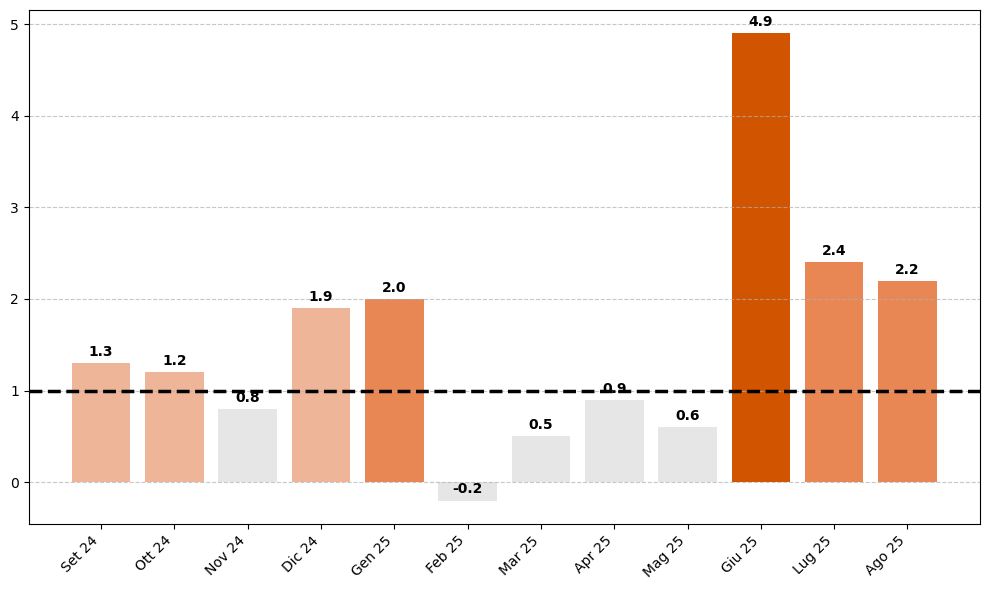

In [ ]:
# Create dataset
categories = ('Set 24','Ott 24','Nov 24','Dic 24','Gen 25','Feb 25','Mar 25','Apr 25','Mag 25', 'Giu 25', 'Lug 25', 'Ago 25')

# Define colors and intervals
colors = ['#E6E6E6', '#EFB598', '#E88754', '#D15400']
intervals = ["<1", "1-2", "2-3", ">3"]

def get_color_for_value(value, colors):
    """
    Assign a color based on the value's interval.

    Parameters:
        value (float): The value to categorize.
        colors (list): List of colors for each interval.

    Returns:
        str: The color corresponding to the value's interval.
    """
    if value < 1:
        return colors[0]  # <1
    elif 1 <= value < 2:
        return colors[1]  # 1-2
    elif 2 <= value < 3:
        return colors[2]  # 2-3
    else:
        return colors[3]  # >3

def create_colorgraded_barplot(categories, values, title):
    """
    Create a color-graded bar plot using Matplotlib.

    Parameters:
        categories (list): List of categories for the x-axis.
        values (list): List of values for the y-axis.
        title (str): Title of the plot.

    Returns:
        None
    """

    # ONLY IN THIS PLOT #########################################################
    # Round values to 1 decimal place before color assignment
    values = [round(v, 1) for v in values]
    #############################################################################

    plt.figure(figsize=(10, 6))  # Adjust the figure size if needed

    # Assign colors to each bar based on its value
    bar_colors = [get_color_for_value(v, colors) for v in values]

    # Create the bar plot with color grading
    bars = plt.bar(categories, values, color=bar_colors)

    # Add a constant line at y=1
    plt.axhline(y=1, color='black', linestyle='--', linewidth=2.5, label='Reference Extreme Value')

    # Rotate x-axis labels if there are many categories for better readability
    if len(categories) > 10:
        plt.xticks(rotation=45, ha='right')

    # Show gridlines to make it easier to read values
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add data labels above each bar
    for bar in bars:
        height = bar.get_height()
        plt.annotate("{:.1f}".format(height), xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()  # Adjusts spacing to prevent clipping of labels

    plt.savefig(f"{path_output}/Grafico Caldo discreto")
    plt.savefig(f"{path_output}/SVG/Grafico Caldo discreto.svg", format="svg")

    # Display the plot
    plt.show()

# Example data
title = 'Cold Stress Index per l\'Italia negli ultimi 12 mesi'

# Call the function to create the color-graded bar plot
create_colorgraded_barplot(categories, values, title)

Final remarks

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.